## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Sherlock Chen

**Date:** 10/2/2026

In [ ]:
# Question 1.1
# Regression is to predict a numeric outcome (answering questions like how many) while classification is to predict a category (answering questions like which class).

# Question 1.2
# A confusion table is something used to split into actual versus predicted classes. It helps with finding where a model makes mistakes such as if there are any false positives or false negatives.

# Question 1.3
# SSE helps tell you a model's overall fit, where 0 represents it fits perfectly, lower values meaning there are only some small errors, and higher values meaning it deviates significantly from the actual.

# Question 1.4
# Underfitting is when the model didn't learn enough and is not able to replicate the pattern to prdict accurately. Overfitting is when the model learned too much and can only replicate the exact training data and fails on anything else even slightly different.

# Question 1.5
# Splitting data into training and testing improves model performance because it prevents the model from simply memorizing answers and allows you to simulate what would happen for predicting actual data. Choosing an optimal "k" also improves model performance it will not overfit or underfit and will be able to predict for real-world data. 

# Question 1.6
# When you predict using class label, it is more direct since it gives you a distinct answer from the other categories. However, it does not show details such as how confident this prediction is. When you predict with probability, it shows how certain the prediction is so you can evaluate it. However, it is not as direct as predicting classes so you need to be able to interpret and give the predicted probability meaning so it can be actionable.

<class 'pandas.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   voltage    338 non-null    float64
 1   height     338 non-null    float64
 2   soil       338 non-null    float64
 3   mine_type  338 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 10.7 KB
None
338
4
voltage      0
height       0
soil         0
mine_type    0
dtype: int64
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
          voltage      height        soil
count  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550
std      0.195819    0.306043    0.344244
min      0.197734    0.000000    0.000000
25%      0.309737    0.272727    0.200000
50%      0.359516    0.545455    0.600000
75%      0.482628    0.727273    0.800000
max      0.999999    1.000000    1.000000
169
169


The most optimal k value chosen is: 2
Accuracy: 0.44970414201183434


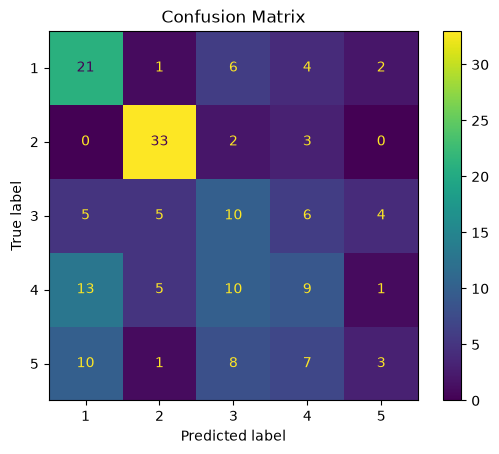

In [ ]:
# Question 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

# Question 2.1

# Load data
df = pd.read_csv("data/land_mines.csv")

# EDA
print(df.info())
print(df.shape[0])
print(df.shape[1])
print(df.isnull().sum())

# Summarize target label
print(df["mine_type"].value_counts())

# Summarize features
print(df[["voltage", "height", "soil"]].describe())

# Question 2.2
eval_X_raw = df[["voltage", "height", "soil"]]
eval_y = df["mine_type"]

# Split 50/50 for training and validation sets
(
    eval_X_train_raw,
    eval_X_valid_raw,
    eval_y_train,
    eval_y_valid,
) = train_test_split(eval_X_raw, eval_y, test_size=0.50, random_state=65)

print(len(eval_y_train))
print(len(eval_y_valid))

# Scaling
eval_scaler = MinMaxScaler()
eval_X_train_scaled = eval_scaler.fit_transform(eval_X_train_raw)
eval_X_valid_scaled = eval_scaler.transform(eval_X_valid_raw)

# Question 2.3

# Similar to the slides showed in class, the most optimal k was chosen by testing k values from 1 to 50, looping through each one to train model and predict on validation and training data, and save accuracy scores. The k value with highest accuracy score was chosen
# The most optimal k chosen here was 2
eval_ks = np.arange(1, 51)
eval_valid_score = []
eval_train_score = []

for eval_k in eval_ks:
  eval_candidate = KNeighborsClassifier(n_neighbors=int(eval_k))
  eval_candidate.fit(eval_X_train_scaled, eval_y_train)
  eval_valid_hat = eval_candidate.predict(eval_X_valid_scaled)
  eval_train_hat = eval_candidate.predict(eval_X_train_scaled)
  eval_valid_score.append(accuracy_score(eval_y_valid, eval_valid_hat))
  eval_train_score.append(accuracy_score(eval_y_train, eval_train_hat))

optimal_k = eval_ks[np.argmax(eval_valid_score)]
print(f"The most optimal k value chosen is: {optimal_k}")

# Final knn using most optimal k value chosen
final_knn = KNeighborsClassifier(n_neighbors=optimal_k)
final_knn.fit(eval_X_train_scaled, eval_y_train)

# Question 2.4

# The accuracy is about 45%
# Performance is most accurate in mine label 2 because it has the most correct predictions out of all the mine labels. All other mine labels were much less accurate, with mine label 5 having the least predictions correct.
eval_valid_hat = final_knn.predict(eval_X_valid_scaled)
print(f"Accuracy: {accuracy_score(eval_y_valid, eval_valid_hat)}")

ConfusionMatrixDisplay.from_predictions(eval_y_valid, eval_valid_hat)
plt.title("Confusion Matrix")
plt.show()

# Question 2.5
# In practice, this model should only be used as a suggestive guide since it has a low overall accuracy.
# For example, here it shows that it does fairly well at predicting mine label 2 (it predicted 33 correct out of total 38) but all the other mine labels were not as accurate meaning as a general guide, mine label 2s are mostly correct but other mine labels should not be trusted to be predicted with this model.






## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]